# AURA Tutorial: NSCLC Lung (CosMx 1K)

This tutorial demonstrates AURA on the **CosMx NSCLC** dataset —
a multi-sample multiplex spatial transcriptomics dataset with a
960-gene panel and 766K cells across 8 samples.

It complements the other tutorials by showing:

1. **CosMx-specific data preparation** — lineage mapping from fine cell types
2. **Multi-sample AURA** on a tumor microenvironment
3. **Beta heatmap** with spillover annotation
4. **Cross-focal comparison** — which composition axes drive expression
   in different immune and stromal populations
5. **Spillover filter** at an intermediate suspect rate (~12%)

### Dataset summary

| Property | Value |
|:---|:---|
| Platform | Nanostring CosMx 1K |
| Cells | 765,771 |
| Genes | 960 |
| Samples | 8 |
| Composition groups | 8 (Tumor, Epithelial, Fibroblast, Macrophage, etc.) |
| Segmentation | CosMx bespoke |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import aura
from aura.io import TissueData

import logging
logging.basicConfig(level=logging.INFO, format='%(name)s: %(message)s')

print(f'AURA version: {aura.__version__}')

AURA version: 0.2.0


In [2]:
# ================================================================
# Paths and parameters
# ================================================================
DATA_PATH = '/Users/mchen12/SpatialHeterogeneity/data/CosMx_NSCLC/cosmx_nsclc_prepped.h5ad'

K = 30
N_PERM = 5000
ALPHA = 0.05

---
## 1. Load and Prepare Data

The CosMx dataset has fine cell types in `cell_type` and lineage groups
in `lineage`. The 8 lineage groups serve as the composition axes.

In [3]:
print(f'Loading {DATA_PATH}...')
adata = sc.read_h5ad(DATA_PATH)
print(f'  Cells: {adata.n_obs:,}, Genes: {adata.n_vars}')
print(f'  Samples: {adata.obs["sample"].nunique()}')
print(f'\nLineage groups:')
for grp in sorted(adata.obs['lineage'].unique()):
    n = (adata.obs['lineage'] == grp).sum()
    print(f'  {grp:14s}: {n:>8,}')

print(f'\nFine cell types ({adata.obs["cell_type"].nunique()}):')
for ct in sorted(adata.obs['cell_type'].unique()):
    n = (adata.obs['cell_type'] == ct).sum()
    print(f'  {ct:18s}: {n:>8,}')

Loading /Users/mchen12/SpatialHeterogeneity/data/CosMx_NSCLC/cosmx_nsclc_prepped.h5ad...


  Cells: 765,771, Genes: 960
  Samples: 8

Lineage groups:
  B_Plasma      :   64,305
  Endothelial   :   37,729
  Epithelial    :   23,937
  Fibroblast    :   93,037
  Granulocyte   :   78,730
  Macrophage    :   91,081
  T_cell        :   74,639
  Tumor         :  302,313

Fine cell types (22):
  B-cell            :   26,329
  NK                :    7,814
  T CD4 memory      :   16,836
  T CD4 naive       :   27,988
  T CD8 memory      :    5,503
  T CD8 naive       :   10,452
  Treg              :    6,046
  endothelial       :   37,729
  epithelial        :   23,937
  fibroblast        :   93,037
  mDC               :   16,673
  macrophage        :   53,067
  mast              :   11,104
  monocyte          :    8,269
  neutrophil        :   67,626
  pDC               :   13,072
  plasmablast       :   37,976
  tumor 12          :   22,434
  tumor 13          :   26,757
  tumor 5           :   52,218
  tumor 6           :   66,805
  tumor 9           :  134,099


In [4]:
def build_tissue(adata):
    """Wrap AnnData as TissueData using 'lineage' as composition column."""
    type_names = sorted(adata.obs['lineage'].unique())
    type_to_int = {t: i for i, t in enumerate(type_names)}
    all_types = np.array([type_to_int[t] for t in adata.obs['lineage']])
    all_xy = adata.obs[['x_centroid', 'y_centroid']].values.astype(np.float64)
    return TissueData(adata=adata, all_xy=all_xy, all_types=all_types,
                      type_names=type_names, type_to_int=type_to_int)

tissue = build_tissue(adata)
print(f'Tissue: {len(tissue.type_names)} composition groups: {tissue.type_names}')

Tissue: 8 composition groups: ['B_Plasma', 'Endothelial', 'Epithelial', 'Fibroblast', 'Granulocyte', 'Macrophage', 'T_cell', 'Tumor']


---
## 2. Run AURA on Two Focal Types

We analyze **macrophages** (tumor-associated immune cells) and
**fibroblasts** (cancer-associated stroma) — both strongly shaped by
the tumor microenvironment.

In [5]:
import time

# Macrophage
t0 = time.time()
result_mac = aura.run_aura_multisample(
    tissue,
    focal_label='macrophage',
    sample_column='sample',
    label_column='cell_type',
    k=K, n_perm=N_PERM, alpha=ALPHA,
)
print(f'Macrophage: {result_mac.n_significant}/{result_mac.n_genes} significant '
      f'({time.time()-t0:.0f}s)')

# Fibroblast
t0 = time.time()
result_fib = aura.run_aura_multisample(
    tissue,
    focal_label='fibroblast',
    sample_column='sample',
    label_column='cell_type',
    k=K, n_perm=N_PERM, alpha=ALPHA,
)
print(f'Fibroblast: {result_fib.n_significant}/{result_fib.n_genes} significant '
      f'({time.time()-t0:.0f}s)')

aura.io: Focal cells (macrophage): 53067


aura.io: Genes (mean >= 0.10): 418


aura.model: Samples: 8, Cells: 53067, Types: 8


aura.model: Cells per sample: min=1291, max=17989, median=6806


aura.model: Dispersion phi = 0.61


...

aura.model: Cells per sample: min=3252, max=16548, median=12722


aura.model: Dispersion phi = 0.80


aura.model: Significant genes: 311 / 378 (FDR < 0.05)


aura.model: Filtered 12 genes with no excess variance (323 before filter)


Fibroblast: 311/378 significant (26s)


---
## 3. Diagnostics

In [6]:
fig = aura.diagnostic_panel(result_mac, title='AURA Diagnostic — Macrophage (NSCLC)')
plt.show()

<Figure size 2000x1500 with 12 Axes>

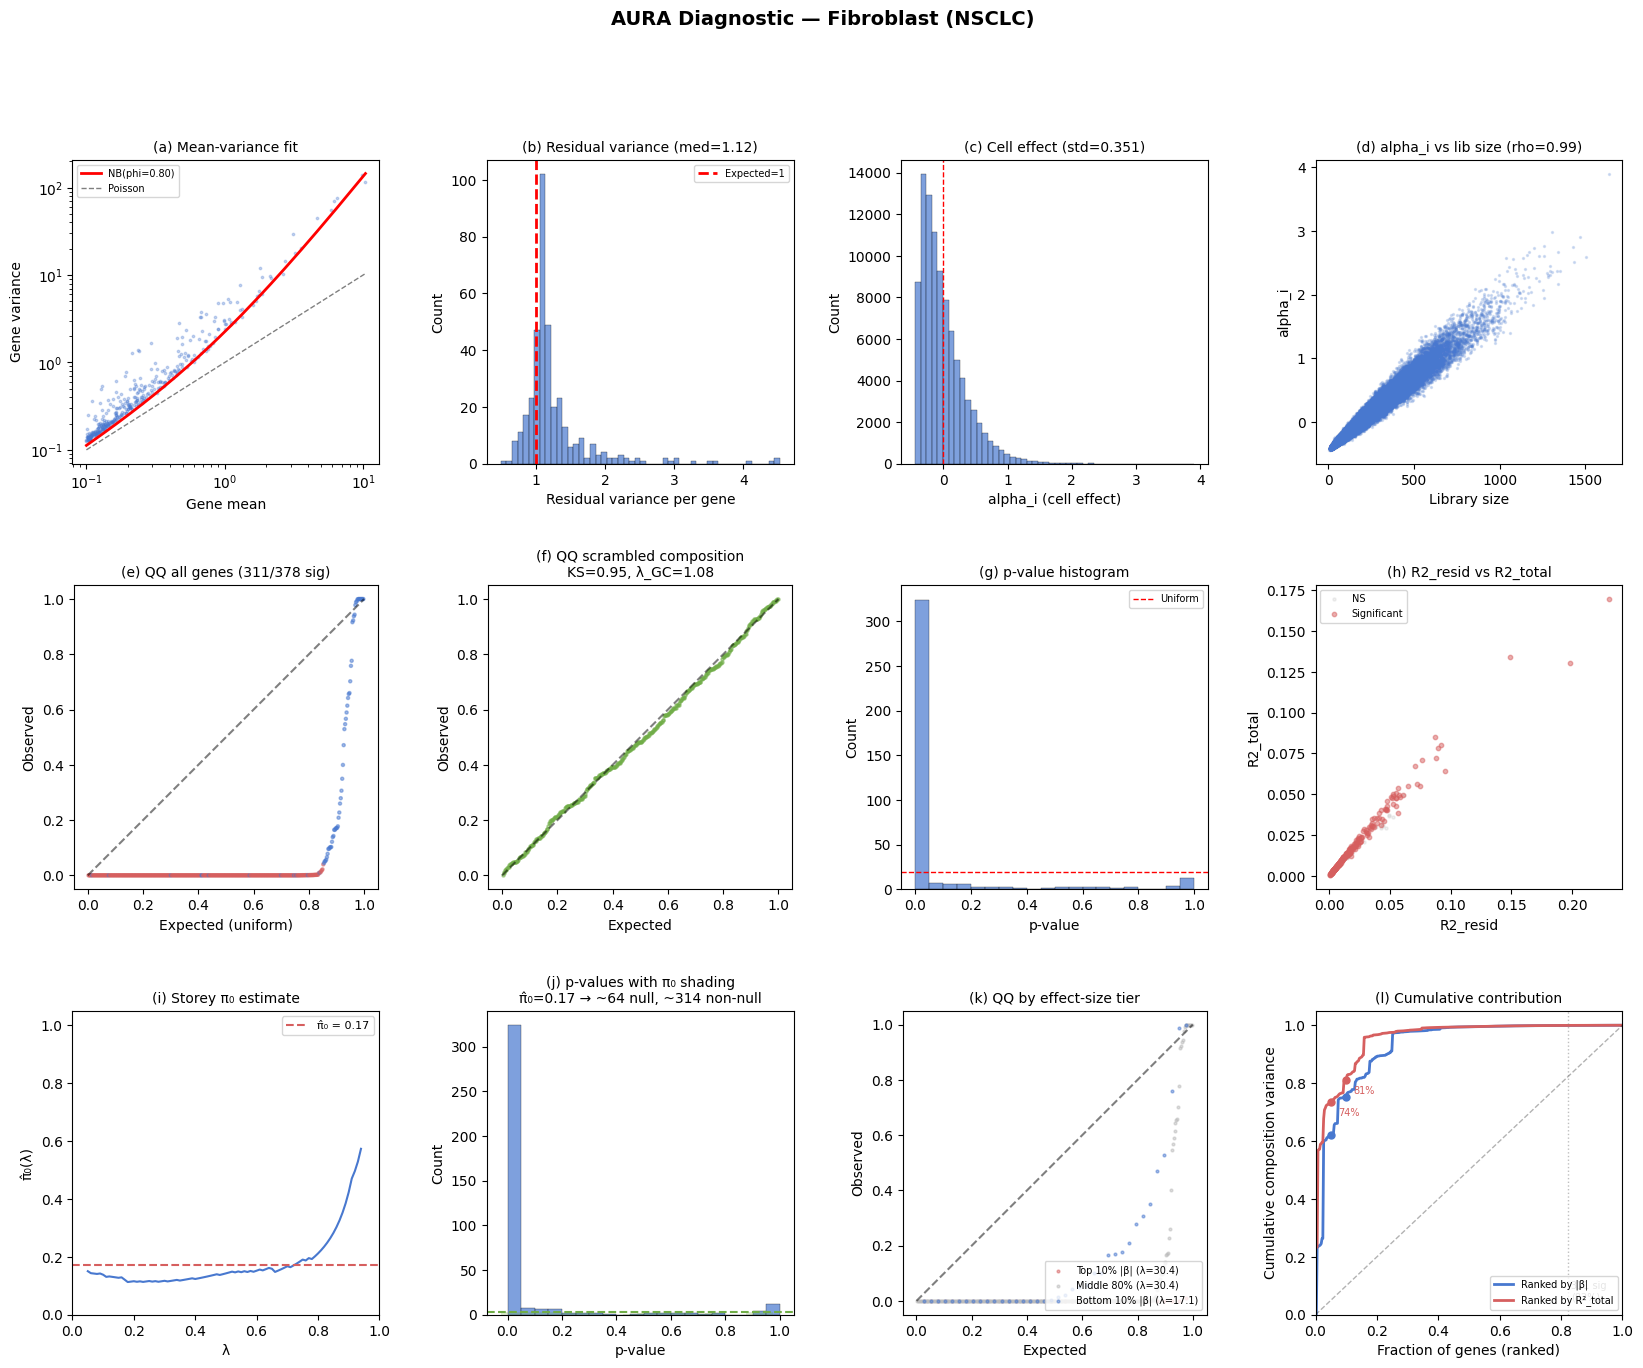

In [7]:
fig = aura.diagnostic_panel(result_fib, title='AURA Diagnostic — Fibroblast (NSCLC)')
plt.show()

---
## 4. Beta Heatmaps

Visualize the full beta matrix as a clustered heatmap with R²_total sidebar.

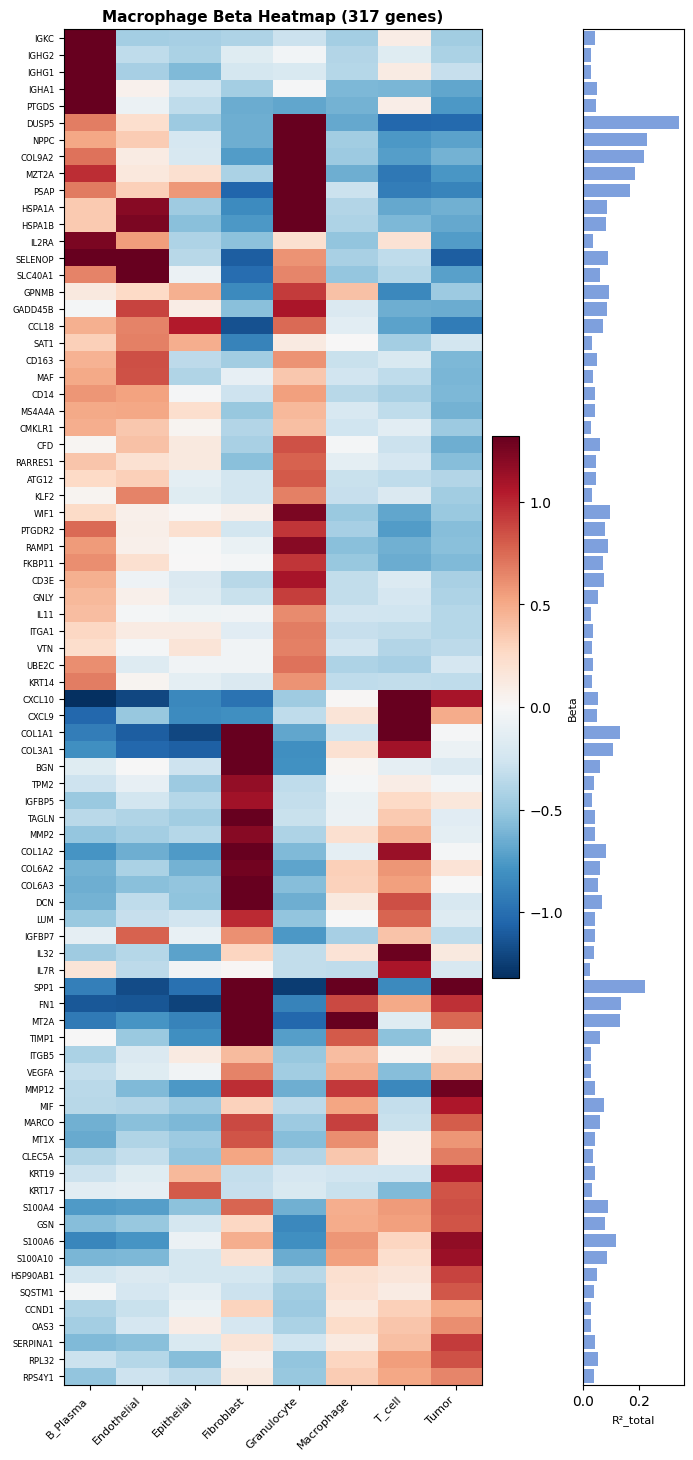

In [8]:
from scipy.cluster.hierarchy import linkage, leaves_list

def beta_heatmap(result, title='Beta Heatmap', max_genes=80):
    """Full beta heatmap of significant genes x composition axes."""
    sig_mask = result.significant
    beta = result.beta[sig_mask]
    genes = result.gene_names[sig_mask]
    r2t = result.R2_total[sig_mask]
    type_names = result.type_names

    order = np.argsort(r2t)[::-1][:max_genes]
    beta_show = beta[order]
    genes_show = genes[order]
    r2_show = r2t[order]

    if len(beta_show) > 2:
        Z = linkage(beta_show, method='ward')
        clust_order = leaves_list(Z)
        beta_show = beta_show[clust_order]
        genes_show = genes_show[clust_order]
        r2_show = r2_show[clust_order]

    n_genes = len(genes_show)
    vmax = np.percentile(np.abs(beta_show), 95)

    fig, (ax_heat, ax_r2) = plt.subplots(
        1, 2, figsize=(8, max(6, n_genes * 0.22)),
        gridspec_kw={'width_ratios': [5, 1], 'wspace': 0.05})

    im = ax_heat.imshow(beta_show, aspect='auto', cmap='RdBu_r',
                        vmin=-vmax, vmax=vmax, interpolation='none')
    ax_heat.set_xticks(range(len(type_names)))
    ax_heat.set_xticklabels(type_names, rotation=45, ha='right', fontsize=8)
    ax_heat.set_yticks(range(n_genes))
    ax_heat.set_yticklabels(genes_show, fontsize=6)
    ax_heat.set_title(title, fontsize=11, fontweight='bold')
    cb = plt.colorbar(im, ax=ax_heat, shrink=0.4, pad=0.02)
    cb.set_label('Beta', fontsize=8)

    ax_r2.barh(range(n_genes), r2_show, color='#4878CF', alpha=0.7, height=0.8)
    ax_r2.set_yticks([])
    ax_r2.set_xlabel('R²_total', fontsize=8)
    ax_r2.invert_yaxis()
    ax_r2.set_ylim(ax_heat.get_ylim())

    plt.tight_layout()
    return fig

fig = beta_heatmap(result_mac,
                   title=f'Macrophage Beta Heatmap ({result_mac.n_significant} genes)')
plt.show()

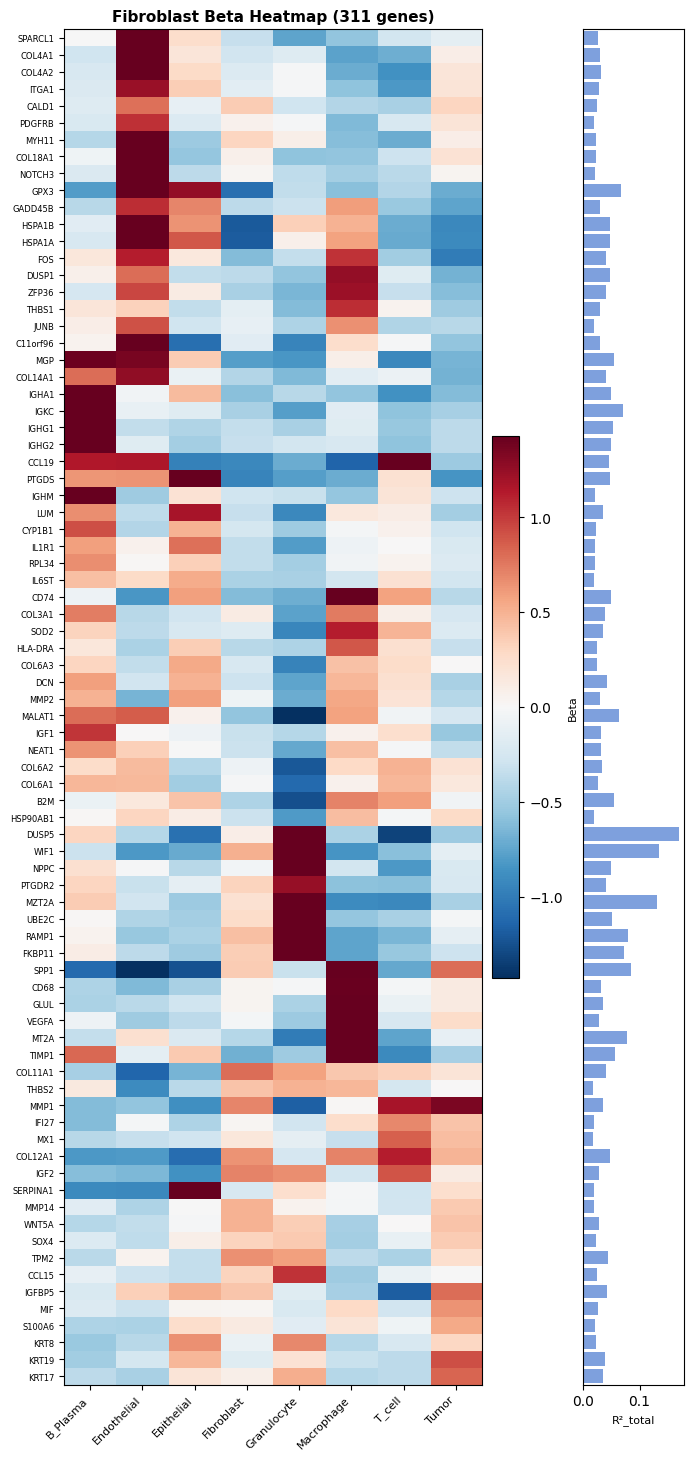

In [9]:
fig = beta_heatmap(result_fib,
                   title=f'Fibroblast Beta Heatmap ({result_fib.n_significant} genes)')
plt.show()

---
## 5. SVD Result Panels

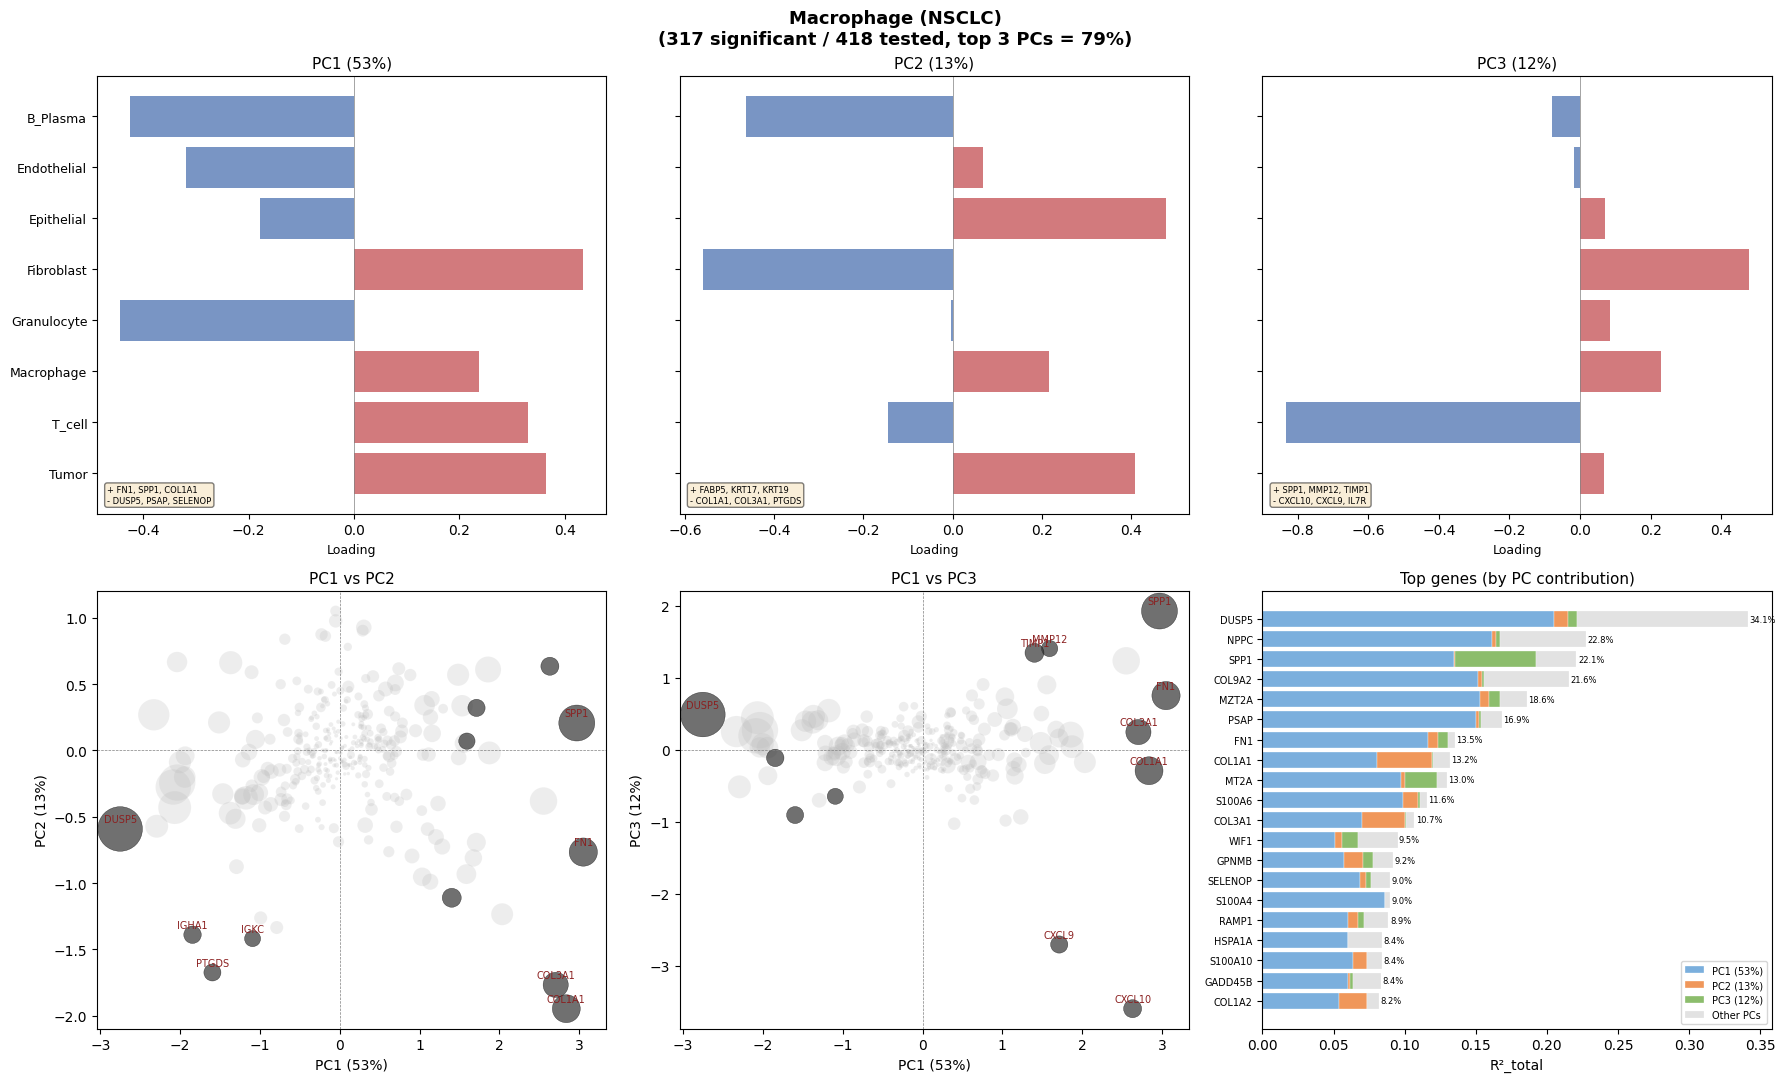

In [10]:
fig = aura.result_panel(result=result_mac, title='Macrophage (NSCLC)')
plt.show()

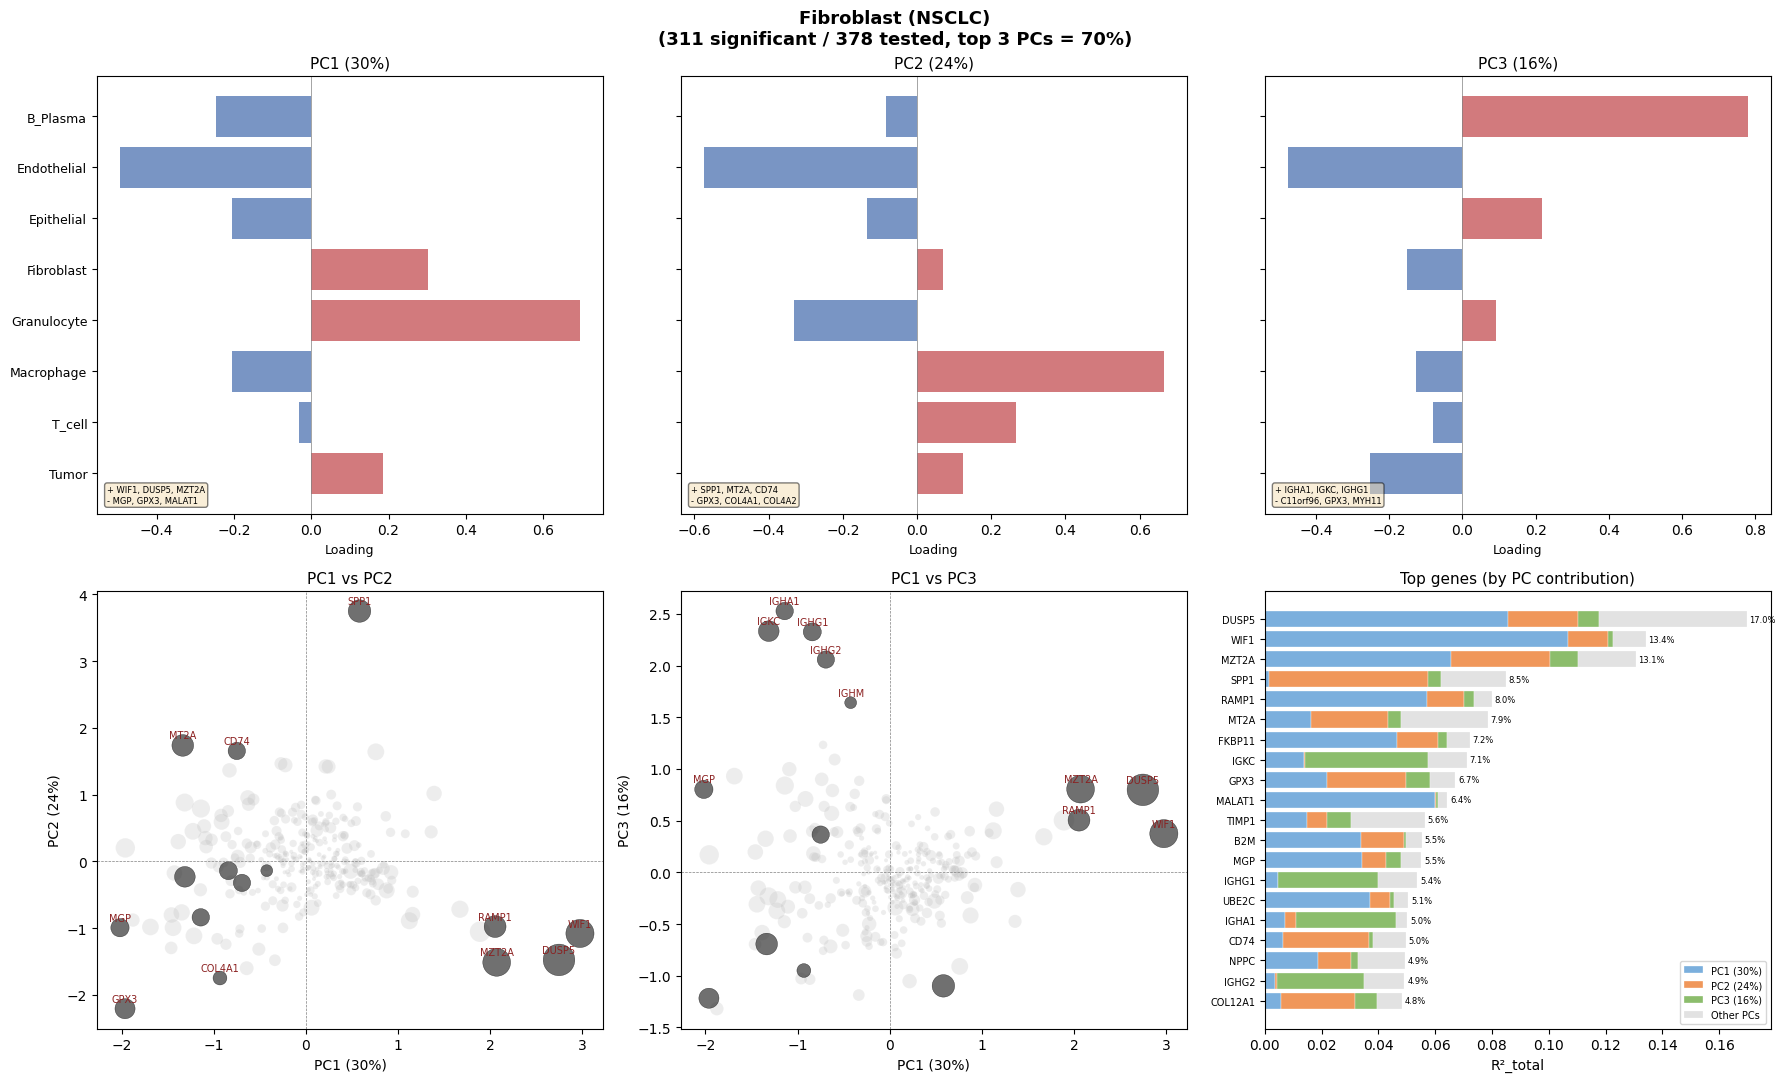

In [11]:
fig = aura.result_panel(result=result_fib, title='Fibroblast (NSCLC)')
plt.show()

---
## 6. Data-Driven Spillover Detection

CosMx has bespoke segmentation — better than default Xenium but not
perfect. We expect ~12% suspect rate.

In [12]:
# Learn canonical markers from the full dataset
canonical, stats_df = aura.learn_canonical(
    adata, type_column='lineage',
    min_fold=2.0, min_detection=0.05,
)

n_markers = sum(len(v) for v in canonical.values())
print(f'Derived {n_markers} canonical markers:\n')
for grp, markers in sorted(canonical.items()):
    if markers:
        preview = ', '.join(sorted(markers)[:6])
        ell = '...' if len(markers) > 6 else ''
        print(f'  {grp:14s} ({len(markers):4d}): {preview}{ell}')

aura.spillover: Learned 282 canonical markers across 8/8 types (min_fold=2.0, min_det=5%)


Derived 282 canonical markers:

  B_Plasma       (  14): CD19, CD79A, IGHA1, IGHD, IGHG1, IGHG2...
  Endothelial    (  34): ACE, ACKR1, ACVRL1, ADGRL2, ADGRL4, CD34...
  Epithelial     (  15): AQP3, CCL20, CLU, CXCL17, CXCL2, DMBT1...
  Fibroblast     (  27): ACTA2, CDH11, COL11A1, COL12A1, COL14A1, COL16A1...
  Granulocyte    (   6): CPA3, CXCL8, IL1RL1, KIT, TPSAB1, TPSB2
  Macrophage     (  38): C1QA, C1QB, C1QC, CCL18, CD14, CD163...
  T_cell         (  14): CCL5, CD2, CD28, CD3G, CD8A, CTLA4...
  Tumor          ( 134): ADGRA3, ADGRL1, AGR2, AHR, AKT1, ANXA4...


In [13]:
# Multi-focal spillover filter
combined = aura.spillover_filter_multi(
    [
        ('macrophage',  result_mac, 'Macrophage'),
        ('fibroblast',  result_fib, 'Fibroblast'),
    ],
    canonical=canonical,
)

print(f'Spillover summary:')
print(f'  Total significant: {len(combined)}')
n_suspect = combined['spillover_suspect'].sum()
print(f'  Clean: {len(combined) - n_suspect}')
print(f'  Suspect: {n_suspect} ({n_suspect/len(combined)*100:.0f}%)\n')

for ft in ['macrophage', 'fibroblast']:
    sub = combined[combined['focal_type'] == ft]
    ns = sub['spillover_suspect'].sum()
    print(f'  {ft:14s}: {len(sub)} total, {len(sub)-ns} clean, {ns} suspect')

aura.spillover: Spillover filter: 317 significant, 42 suspect (13%), 275 clean


aura.spillover: Spillover filter: 311 significant, 44 suspect (14%), 267 clean


aura.spillover: spillover_filter_multi: 2 focal types, 628 total significant, 542 clean, 86 spillover-suspect


Spillover summary:
  Total significant: 628
  Clean: 542
  Suspect: 86 (14%)

  macrophage    : 317 total, 275 clean, 42 suspect
  fibroblast    : 311 total, 267 clean, 44 suspect


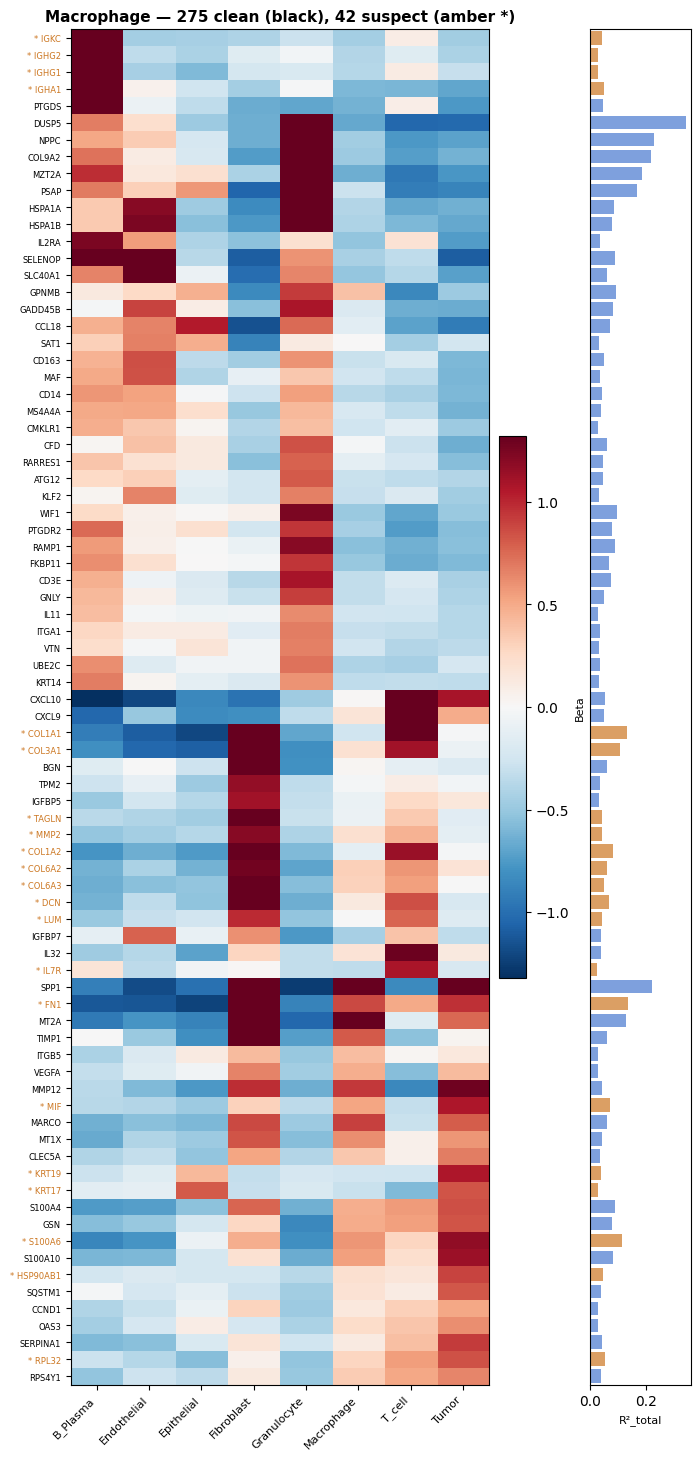

In [14]:
# Annotated heatmap for macrophage
spill_mac = combined[combined['focal_type'] == 'macrophage']
suspect_set = set(spill_mac[spill_mac['spillover_suspect']]['gene'])

def beta_heatmap_annotated(result, suspect_set, title='', max_genes=80):
    """Beta heatmap with spillover suspects highlighted."""
    sig_mask = result.significant
    beta = result.beta[sig_mask]
    genes = result.gene_names[sig_mask]
    r2t = result.R2_total[sig_mask]
    type_names = result.type_names

    order = np.argsort(r2t)[::-1][:max_genes]
    beta_show = beta[order]
    genes_show = genes[order]
    r2_show = r2t[order]

    if len(beta_show) > 2:
        Z = linkage(beta_show, method='ward')
        clust_order = leaves_list(Z)
        beta_show = beta_show[clust_order]
        genes_show = genes_show[clust_order]
        r2_show = r2_show[clust_order]

    n_genes = len(genes_show)
    vmax = np.percentile(np.abs(beta_show), 95)

    fig, (ax_heat, ax_r2) = plt.subplots(
        1, 2, figsize=(8, max(6, n_genes * 0.22)),
        gridspec_kw={'width_ratios': [5, 1], 'wspace': 0.05})

    im = ax_heat.imshow(beta_show, aspect='auto', cmap='RdBu_r',
                        vmin=-vmax, vmax=vmax, interpolation='none')
    ax_heat.set_xticks(range(len(type_names)))
    ax_heat.set_xticklabels(type_names, rotation=45, ha='right', fontsize=8)
    ax_heat.set_yticks(range(n_genes))
    labels = [f'* {g}' if g in suspect_set else g for g in genes_show]
    ax_heat.set_yticklabels(labels, fontsize=6)
    for i, lab in enumerate(ax_heat.get_yticklabels()):
        if genes_show[i] in suspect_set:
            lab.set_color('#CC7722')
    ax_heat.set_title(title, fontsize=11, fontweight='bold')
    cb = plt.colorbar(im, ax=ax_heat, shrink=0.4, pad=0.02)
    cb.set_label('Beta', fontsize=8)

    colors = ['#CC7722' if g in suspect_set else '#4878CF' for g in genes_show]
    ax_r2.barh(range(n_genes), r2_show, color=colors, alpha=0.7, height=0.8)
    ax_r2.set_yticks([])
    ax_r2.set_xlabel('R²_total', fontsize=8)
    ax_r2.invert_yaxis()
    ax_r2.set_ylim(ax_heat.get_ylim())

    plt.tight_layout()
    return fig

n_clean = len(spill_mac) - len(suspect_set)
fig = beta_heatmap_annotated(
    result_mac, suspect_set,
    title=f'Macrophage — {n_clean} clean (black), {len(suspect_set)} suspect (amber *)')
plt.show()

---
## 7. Cross-Focal Comparison

Compare which composition axes drive gene expression across
macrophages and fibroblasts in the tumor microenvironment.

In [15]:
# Shared significant genes
mac_genes = set(result_mac.gene_names[result_mac.significant])
fib_genes = set(result_fib.gene_names[result_fib.significant])
shared = mac_genes & fib_genes

print(f'Macrophage significant: {len(mac_genes)}')
print(f'Fibroblast significant: {len(fib_genes)}')
print(f'Shared: {len(shared)}')

if shared:
    print(f'\nTop shared genes (by mean R²):')
    rows = []
    for g in shared:
        r2_mac = result_mac.R2_total[result_mac.gene_names == g][0]
        r2_fib = result_fib.R2_total[result_fib.gene_names == g][0]
        rows.append({'gene': g, 'R2_mac': r2_mac, 'R2_fib': r2_fib,
                     'mean_R2': (r2_mac + r2_fib) / 2})
    shared_df = pd.DataFrame(rows).sort_values('mean_R2', ascending=False)
    print(shared_df.head(15).to_string(index=False))

Macrophage significant: 317
Fibroblast significant: 311
Shared: 186

Top shared genes (by mean R²):
  gene   R2_mac   R2_fib  mean_R2
 DUSP5 0.341169 0.169676 0.255423
 MZT2A 0.185859 0.130611 0.158235
  SPP1 0.220838 0.084861 0.152850
  NPPC 0.227508 0.049342 0.138425
  WIF1 0.094999 0.134147 0.114573
  MT2A 0.129593 0.078567 0.104080
  PSAP 0.168522 0.016189 0.092356
 RAMP1 0.088652 0.079964 0.084308
COL3A1 0.106833 0.038719 0.072776
FKBP11 0.069193 0.072163 0.070678
S100A6 0.115544 0.020866 0.068205
HSPA1A 0.084356 0.047748 0.066052
HSPA1B 0.079832 0.047868 0.063850
PTGDR2 0.077582 0.040158 0.058870
 TIMP1 0.059435 0.056288 0.057862


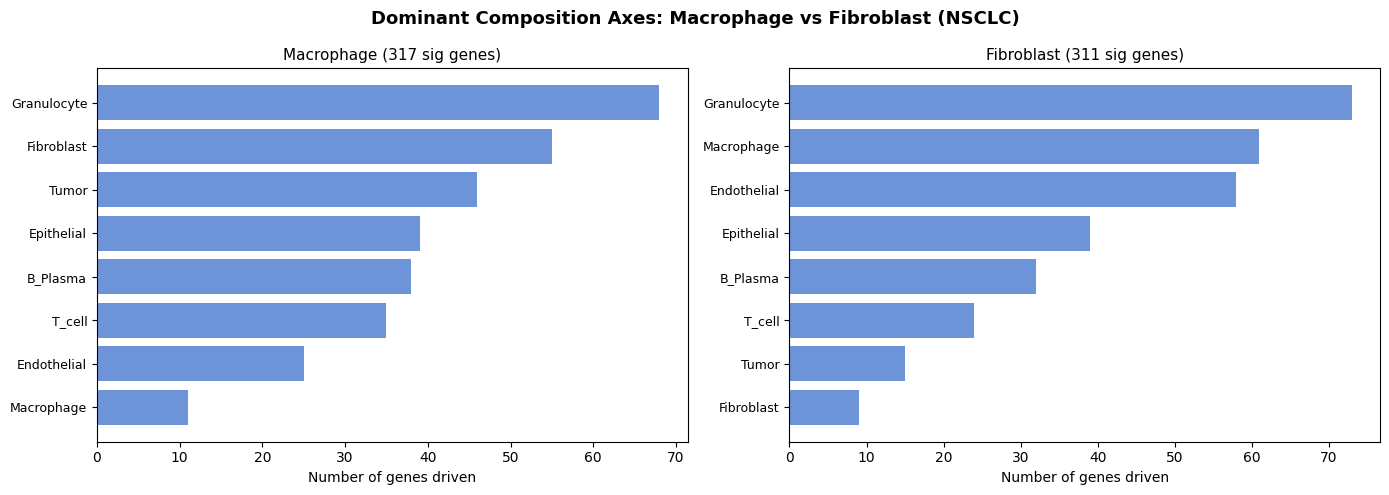

In [16]:
# Driver axis comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dominant Composition Axes: Macrophage vs Fibroblast (NSCLC)',
             fontsize=13, fontweight='bold')

for ax, (res, name) in zip(axes, [(result_mac, 'Macrophage'),
                                   (result_fib, 'Fibroblast')]):
    sig_mask = res.significant
    if sig_mask.sum() == 0:
        continue
    betas = res.beta[sig_mask]
    drivers = np.argmax(np.abs(betas), axis=1)
    counts_per_axis = np.bincount(drivers, minlength=len(res.type_names))
    order = np.argsort(counts_per_axis)[::-1]
    ax.barh(range(len(res.type_names)), counts_per_axis[order],
            color='#4878CF', alpha=0.8)
    ax.set_yticks(range(len(res.type_names)))
    ax.set_yticklabels([res.type_names[i] for i in order], fontsize=9)
    ax.set_xlabel('Number of genes driven')
    ax.set_title(f'{name} ({sig_mask.sum()} sig genes)', fontsize=11)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 8. Distance-Decay Validation

Validate a spillover-suspect gene with the distance-decay test.


  Spillover Distance Test: FN1
  Driver type: Fibroblast
  Cells with driver neighbors: 53,067/53,067
  Median distance to nearest driver: 161 µm

      Distance  n_cells   Det%   Mean  Ctrl_det%
     20-30   µm      333 53.2%  1.60     92.2%
     30-50   µm    4,199 52.3%  1.66     91.9%
     50-100  µm   12,532 48.9%  1.70     93.1%
    100-200  µm   13,698 34.7%  1.14     92.9%
    200-500  µm   17,124 20.0%  0.55     91.1%
    500-1000 µm    4,786 16.4%  0.37     89.2%

  FN1 fold-decay (near/far): 3.2x
  Control (CD74) fold-change: 1.0x

  ** LIKELY SPILLOVER: decays 3x while control is stable.


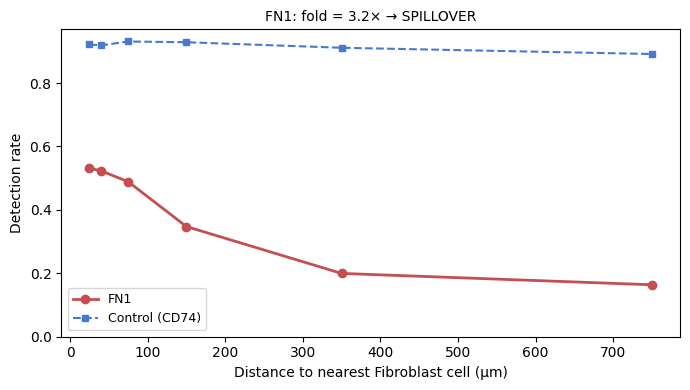

In [17]:
suspects = spill_mac[spill_mac['spillover_suspect']]

if len(suspects) > 0:
    top_suspect = suspects.sort_values('R2_total', ascending=False).iloc[0]
    gene_name = top_suspect['gene']
    driver_axis = top_suspect['driver_axis']
    driver_idx = tissue.type_to_int[driver_axis]

    # Build sample ID arrays
    from scipy.spatial import cKDTree
    sample_names = sorted(adata.obs['sample'].unique())
    sample_to_int = {s: i for i, s in enumerate(sample_names)}
    all_sample_ids = np.array([sample_to_int[s] for s in adata.obs['sample']])
    tree = cKDTree(tissue.all_xy)
    _, idx = tree.query(result_mac.focal_xy, k=1)
    focal_sample_ids = all_sample_ids[idx]

    verdict = aura.spillover_distance_test(
        gene_name=gene_name,
        focal_xy=result_mac.focal_xy,
        focal_counts=result_mac.counts,
        focal_gene_names=result_mac.gene_names,
        focal_sample_ids=focal_sample_ids,
        all_xy=tissue.all_xy,
        all_types=tissue.all_types,
        all_sample_ids=all_sample_ids,
        driver_type_idx=driver_idx,
        type_names=np.array(tissue.type_names),
        verbose=True,
    )

    # Plot
    if len(verdict['bins_df']) >= 2:
        bins_df = verdict['bins_df']
        mid = (bins_df['dist_lo'] + bins_df['dist_hi']) / 2

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(mid, bins_df['detection_rate'], 'o-', color='#C44E52',
                lw=2, markersize=6, label=gene_name)
        ax.plot(mid, bins_df['control_detection'], 's--', color='#4878CF',
                lw=1.5, markersize=5, label=f'Control ({verdict["control_gene"]})')
        ax.set_xlabel(f'Distance to nearest {driver_axis} cell (µm)')
        ax.set_ylabel('Detection rate')
        ax.set_title(f'{gene_name}: fold = {verdict["fold_decay"]:.1f}× → '
                     f'{verdict["verdict"].upper()}', fontsize=10)
        ax.legend(fontsize=9)
        ax.set_ylim(bottom=0)
        plt.tight_layout()
        plt.show()
else:
    print('No spillover-suspect genes to test.')

---
## 9. Save Results

In [18]:
import os
os.makedirs('results', exist_ok=True)

result_mac.save('results/aura_macrophage.csv')
result_fib.save('results/aura_fibroblast.csv')
combined.to_csv('results/spillover_summary_nsclc.csv', index=False)

print('Saved:')
print('  results/aura_macrophage.csv')
print('  results/aura_fibroblast.csv')
print('  results/spillover_summary_nsclc.csv')

aura.io: Saved results: results/aura_macrophage.csv (418 genes, 317 significant)


aura.io: Saved results: results/aura_fibroblast.csv (378 genes, 311 significant)


Saved:
  results/aura_macrophage.csv
  results/aura_fibroblast.csv
  results/spillover_summary_nsclc.csv


---
## Summary

This tutorial demonstrated AURA on the CosMx NSCLC tumor microenvironment:

1. **CosMx data prep** — lineage-level composition groups from fine cell types
2. **Multi-sample AURA** — within-sample kNN and permutation across 8 samples
3. **Beta heatmap** — clustered visualization with R²_total sidebar
4. **Spillover filter** — data-driven canonical markers + multi-focal filter
5. **Distance-decay validation** — spatial confirmation of suspect genes
6. **Cross-focal comparison** — which TME axes drive expression in different
   cell populations

### Comparison across tutorials

| Feature | Lymph Node | IPF | NSCLC |
|:---|:---|:---|:---|
| Mode | Single-sample | Multi-sample | Multi-sample |
| `run_aura` | `run_aura()` | `run_aura_multisample()` | `run_aura_multisample()` |
| Spillover | Low (2%) | High (17%) | Intermediate (12%) |
| Key biology | GC niche → Tfh | Fibrotic niche → AT2 | TME → TAMs |